# CNN Model for Handwritten Digit Recognition - EMNIST Dataset

The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19  and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
import numpy as np

In [5]:
# CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 36)  # 36 classes (0-9, A-Z)

    def forward(self, x):
        x = nn.ReLU()(self.conv1(x))
        x = nn.MaxPool2d(2)(x)
        x = nn.ReLU()(self.conv2(x))
        x = nn.MaxPool2d(2)(x)
        x = x.view(-1, 64 * 5 * 5)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

In [8]:
import torch
from torchvision import datasets, transforms
from PIL import Image

# Mapping function (0-9 -> 0-9, A-Z -> 10-35)
def map_emnist_labels(label):
    if label < 36:
        return label
    return None

class FilteredEMNISTDataset(datasets.EMNIST):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Vectorized filtering for speed
        mask = self.targets < 36
        self.data = self.data[mask]
        self.targets = self.targets[mask]

    def __getitem__(self, index):
        img, target = self.data[index], int(self.targets[index])

        # Convert tensor to PIL Image to apply standard PyTorch transforms correctly
        img = Image.fromarray(img.numpy(), mode='L')

        if self.transform is not None:
            img = self.transform(img)

        return img, target

# Standard transform pipeline (ToTensor converts [0, 255] to [0.0, 1.0])
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load and filter dataset
emnist_data = FilteredEMNISTDataset(root='./data', split='balanced', train=True, download=True, transform=transform)

In [9]:
len(emnist_data)

86400

In [10]:
# Split into train and test sets
train_size = int(0.8 * len(emnist_data))
test_size = len(emnist_data) - train_size
train_data, test_data = random_split(emnist_data, [train_size, test_size])

# Data loaders
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Label map for visualization
labels_map = {i: chr(48 + i) if i < 10 else chr(65 + i - 10) for i in range(36)}  # 0-9 and A-Z

Number of classes: 36
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


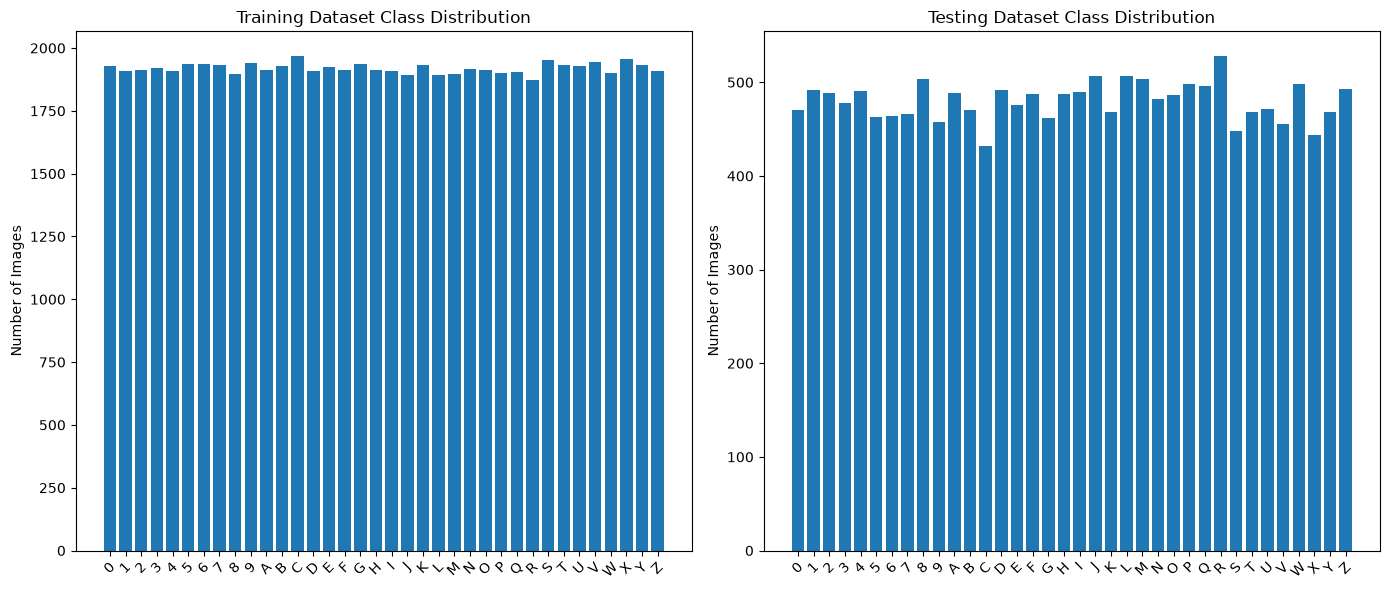

In [11]:
# Print class info using our mapping
print(f"Number of classes: {len(labels_map)}")
print(f"Classes: {list(labels_map.values())}")

# Count the number of images per class
train_indices = train_data.indices
test_indices = test_data.indices

train_counts = Counter([int(emnist_data.targets[i]) for i in train_indices])
test_counts = Counter([int(emnist_data.targets[i]) for i in test_indices])

# Get the number of classes and labels
classes = list(labels_map.values())

# Plot the distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Training dataset distribution
ax[0].bar(classes, [train_counts.get(i, 0) for i in range(len(classes))])
ax[0].set_title("Training Dataset Class Distribution")
ax[0].set_xticks(range(len(classes)))
ax[0].set_xticklabels(classes, rotation=45)
ax[0].set_ylabel("Number of Images")

# Testing dataset distribution
ax[1].bar(classes, [test_counts.get(i, 0) for i in range(len(classes))])
ax[1].set_title("Testing Dataset Class Distribution")
ax[1].set_xticks(range(len(classes)))
ax[1].set_xticklabels(classes, rotation=45)
ax[1].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

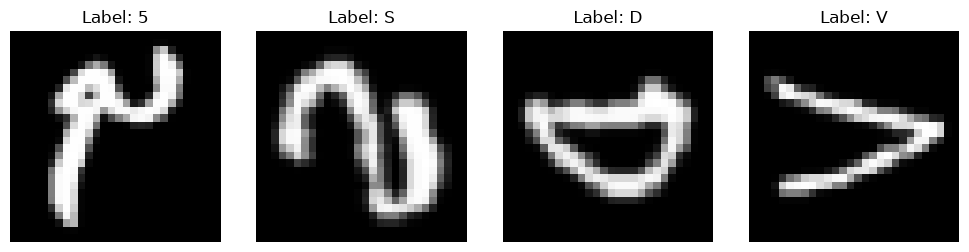

In [12]:
# Visualize random images
def visualize_random_images(dataset, num_images=4):
    fig, axes = plt.subplots(1, num_images, figsize=(10, 2.5))
    for i in range(num_images):
        random_idx = torch.randint(0, len(dataset), size=(1,)).item()
        img, label = dataset[random_idx]
        
        # Un-normalize image from [-1, 1] back to [0, 1] for visualization
        img = img * 0.5 + 0.5
        img = img.squeeze().numpy()  # Remove channel dimension and convert to numpy
        
        # Note: target label is an integer directly, so no .item() needed
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {labels_map[label]}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Call the function to display images
visualize_random_images(emnist_data)

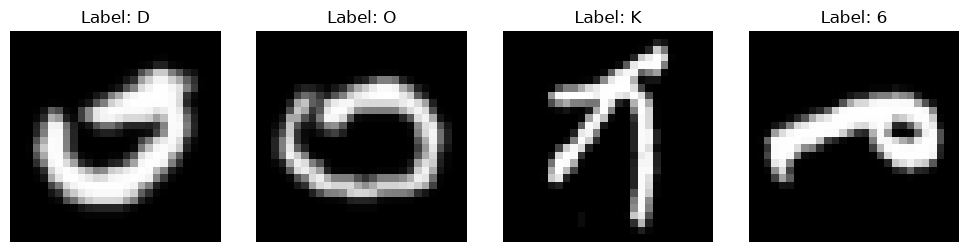

In [13]:
visualize_random_images(train_data)

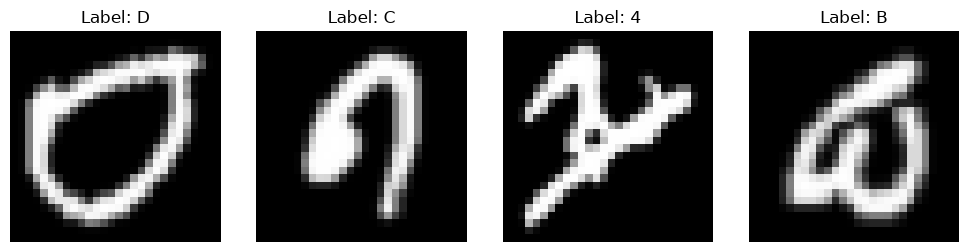

In [14]:
visualize_random_images(train_data)

In [15]:
# Device configuration (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize model, loss, and optimizer
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
for epoch in range(epochs):
    # Training phase
    model.train()
    total_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)

    # Validation phase
    model.eval()
    total_val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch + 1}/{epochs}] | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_accuracy:.2f}%")

Epoch [1/10] | Train Loss: 0.6046 | Val Loss: 0.3537 | Val Acc: 87.26%
Epoch [2/10] | Train Loss: 0.3059 | Val Loss: 0.3075 | Val Acc: 88.90%
Epoch [3/10] | Train Loss: 0.2612 | Val Loss: 0.2844 | Val Acc: 89.46%
Epoch [4/10] | Train Loss: 0.2294 | Val Loss: 0.2953 | Val Acc: 89.32%
Epoch [5/10] | Train Loss: 0.2061 | Val Loss: 0.2676 | Val Acc: 90.28%
Epoch [6/10] | Train Loss: 0.1874 | Val Loss: 0.2878 | Val Acc: 90.09%
Epoch [7/10] | Train Loss: 0.1734 | Val Loss: 0.2763 | Val Acc: 90.41%
Epoch [8/10] | Train Loss: 0.1602 | Val Loss: 0.2951 | Val Acc: 90.18%
Epoch [9/10] | Train Loss: 0.1503 | Val Loss: 0.3040 | Val Acc: 89.60%
Epoch [10/10] | Train Loss: 0.1400 | Val Loss: 0.3472 | Val Acc: 89.58%



Accuracy: 0.8958
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.76      0.68       470
           1       0.49      0.90      0.64       492
           2       0.95      0.77      0.85       489
           3       0.96      0.98      0.97       478
           4       0.90      0.95      0.92       491
           5       0.94      0.86      0.90       463
           6       0.97      0.88      0.92       464
           7       0.95      0.98      0.97       466
           8       0.98      0.94      0.96       503
           9       0.98      0.95      0.97       458
           A       0.97      0.96      0.96       489
           B       0.91      0.98      0.95       470
           C       0.91      0.98      0.94       432
           D       0.95      0.93      0.94       492
           E       0.99      0.96      0.98       476
           F       0.99      0.92      0.96       487
           G       0.86      0.95      0

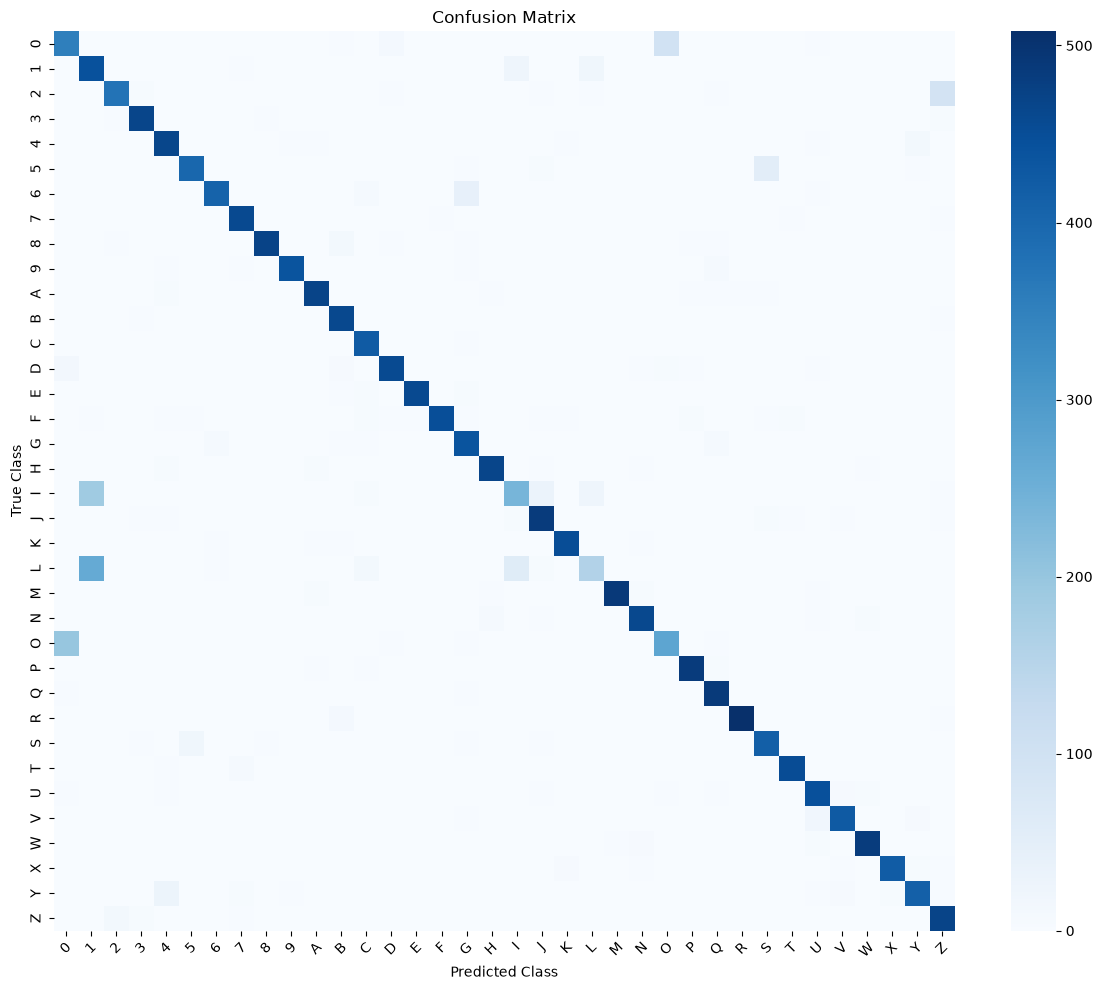

In [16]:
# Evaluation
model.eval()
all_preds = []
all_labels = []

# Ensure device compatibility
device = next(model.parameters()).device

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        # Move tensors to CPU before converting to numpy
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy() if isinstance(labels, np.ndarray) else labels.cpu().numpy())

class_names = [labels_map[i] for i in range(36)]

# Metrics using Sklearn
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=False, cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Save the trained model
torch.save(model.state_dict(), "emnist_cnn.pth")
print("Model saved as emnist_cnn.pth")

Model saved as emnist_cnn.pth


In [18]:
# Select appropriate device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Re-initialize and load state dict safely
model = CNN().to(device)
model.load_state_dict(torch.load("emnist_cnn.pth", map_location=device, weights_only=True))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        # Safely move tensors back to CPU before calling numpy
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy() if isinstance(labels, np.ndarray) else labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")


Accuracy: 0.8958


In [ ]:
import torch
import torch.nn.functional as F
import gradio as gr
from PIL import Image, ImageOps

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
model.load_state_dict(torch.load("emnist_cnn.pth", map_location=device, weights_only=True))
model.eval()

# Correct label map for Digits (0-9) followed by Uppercase Letters (A-Z)
labels_map = {i: str(i) for i in range(10)}
labels_map.update({i + 10: chr(ord('A') + i) for i in range(26)})

# Normalization pipeline
preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

def predict(image):
    if image is None:
        return {}
    
    # 1. Extract composition layer
    if isinstance(image, dict):
        image = image.get("composite", image.get("background", None))
    
    if image is None:
        return {}

    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
        
    # 2. Render solid white background
    image = image.convert("RGBA")
    background = Image.new("RGBA", image.size, (255, 255, 255))
    alpha_composite = Image.alpha_composite(background, image).convert("L")

    # 3. Invert colors (Black ink -> White text)
    inverted_image = ImageOps.invert(alpha_composite)

    # 4. EMNIST orientation transformation
    corrected_image = inverted_image.transpose(Image.ROTATE_270).transpose(Image.FLIP_LEFT_RIGHT)

    # 5. Inference
    img_tensor = preprocess(corrected_image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]
    
    # Return mapped predictions
    return {labels_map[i]: float(probabilities[i]) for i in range(len(labels_map))}

interface = gr.Interface(
    fn=predict,
    inputs=gr.Sketchpad(type="pil"),
    outputs=gr.Label(num_top_classes=5),
    title="Handwritten Character Recognition (EMNIST)",
    description="Draw a digit (0–9) or uppercase letter (A–Z) to test the trained model."
)

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7869
* Running on public URL: https://496f9161b888f52359.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
